In [1]:
!pip install -qq ipywidgets
!apt-get install -qq -y graphviz graphviz-dev && pip install -qq pydot
!pip install -qq pygraphviz

Selecting previously unselected package libatk1.0-data.
(Reading database ... 120314 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../04-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ...
Unpacking libgtk2.0-0:amd64 (2.24.33-2ubuntu2.1) ...
Selecting previously u

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
# os.environ["KERAS_BACKEND"] = "tensorflow"

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

import sklearn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, PredictionErrorDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
## -- keras library --
import tensorflow as tf
from tensorflow.keras.utils import FeatureSpace
from tensorflow.keras.utils import plot_model

import warnings

2026-05-20 12:46:00.580183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779281160.778038      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779281160.843263      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779281161.354477      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779281161.354542      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779281161.354545      16 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --

# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
class CFG():
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

tf.keras.utils.set_random_seed(CFG.SEED)

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    "figure.facecolor": '#0f0f1a', # Outer panel (stage)
    "axes.facecolor":   '#1a1a2e', # Inner panel (plot)
    "axes.edgecolor":   '#444466',
    "axes.labelcolor":  '#e0e0ff',
    "text.color":       'lightblue',
    "xtick.color":      '#e0e0ff',
    "ytick.color":      '#e0e0ff',
    "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

train[TARGET] = train[TARGET].astype('int8')
orig[TARGET] = orig[TARGET].astype('int8')

train_main = train.copy() # Save main default experimenting

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [7]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [8]:
train[NUMS].describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000


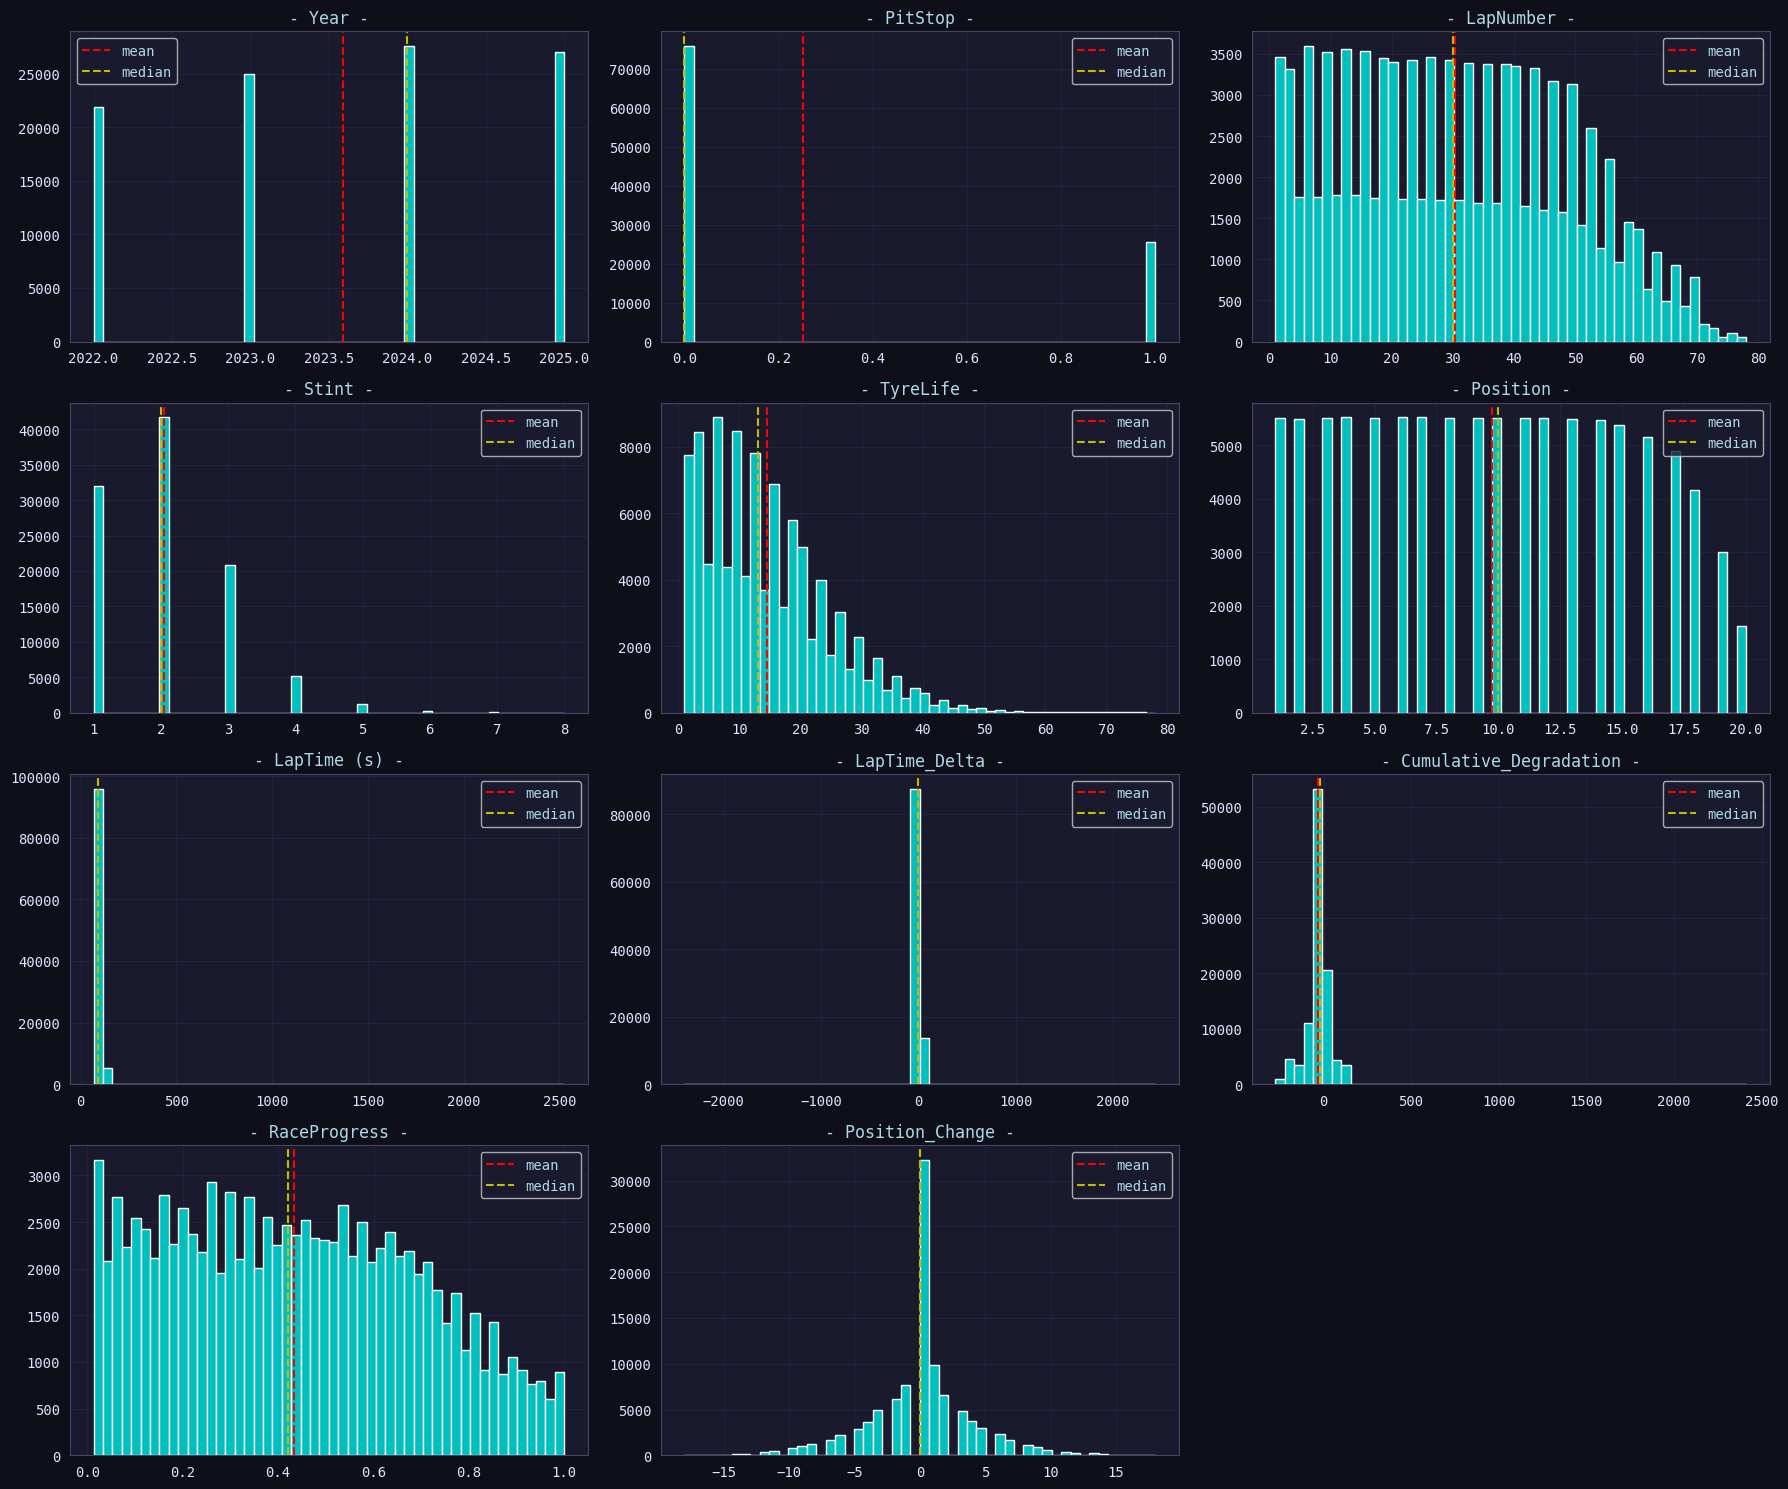

In [9]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [11]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

In [12]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [13]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# _extract_cols = ['Cumulative_Degradation', 'LapTime (s)', 'LapTime_Delta'] # 'LapTime_Delta'

# for col in _extract_cols:
#     print(f"\nRounding... ", end='')
#     for r in [-2, -1, 0, 1, 2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')

#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [-3, -2, -1, 0, 1, 2, 3]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [15]:
# print(f"\nRounding... ", end='')
# for col in ['LapTime (s)']:
#     for r in [-2, -1, 0, 1, 2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [0, 1, 2, 3, 4, 5, 6]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [16]:
# train = train.drop(columns=DROP_COLS)
# test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

# print(f"Features dropped: {DROP_COLS}")

In [17]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [18]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [19]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in n_unique.index[1:10]:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")

In [20]:
## -- Arithmetic interactions --
for df in [train, test, orig]:
    df['_LapNumber_div_RaceProgress'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
    df['_TyreLife_div_LapNumber'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
    df['_LapTime(s)_*_Cumulative_Degradation'] = (df['LapTime (s)'] * df['Cumulative_Degradation']).astype('float32')
    df['_LapTime(s)_*_Cumulative_Degradation_abs'] = (df['LapTime (s)'] * df['Cumulative_Degradation'].abs()).astype('float32')
    df['_LapTime(s)_div_Cumulative_Degradation_abs'] = (df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + 1e-6)).astype('float32')

arithmetic = [
    '_LapNumber_div_RaceProgress',
    '_TyreLife_div_LapNumber',
    '_LapTime(s)_*_Cumulative_Degradation',
    '_LapTime(s)_*_Cumulative_Degradation_abs',
    '_LapTime(s)_div_Cumulative_Degradation_abs',
]

print(f"Total Arithmetic interactions: {len(arithmetic)}")

train[arithmetic].describe()

Total Arithmetic interactions: 5


,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime(s)_*_Cumulative_Degradation,_LapTime(s)_*_Cumulative_Degradation_abs,_LapTime(s)_div_Cumulative_Degradation_abs
count,439140.000000,439140.000000,4.391400e+05,4.391400e+05,4.391400e+05
mean,69.990829,0.788312,-2.116607e+03,3.792920e+03,2.541854e+06
std,9.526926,0.428522,2.998725e+04,2.980661e+04,1.684471e+07
min,0.999999,0.014493,-3.921075e+04,0.000000e+00,3.363055e-02
25%,69.999741,0.489796,-4.063407e+03,1.086443e+03,1.579544e+00
50%,71.999832,1.000000,-1.948616e+03,2.436394e+03,3.346379e+00
75%,75.999893,1.000000,-5.739720e+02,4.709792e+03,7.945557e+00
max,531.989868,25.000000,6.011753e+06,6.011753e+06,2.483738e+09


In [21]:
# train[arithmetic].describe()

In [22]:
# ## -- Cyclic encoding --
# CYCLICS = []

# for col in ['MonthlyCharges', 'TotalCharges']:
#     for p in [12, 30]:
#         n_s = f'{col}_sin_{p}'
#         n_c = f'{col}_cos_{p}'
#         train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
#         train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')

#         test[n_s] = np.sin(2 * np.pi * test[col] / p).astype('float32')
#         test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')

#         orig[n_s] = np.sin(2 * np.pi * orig[col] / p).astype('float32')
#         orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')

#         CYCLICS += [n_s, n_c]

# print(f"Cylcic Features created: {len(CYCLICS)}")
# train[CYCLICS].head(3)

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [24]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [25]:
## -- Apply log transformation --
for df in [train, test, orig]:
    df['_log_RaceProgress'] = np.log(df['RaceProgress'])
    df['_log_LapTime_s'] = np.log(df['LapTime (s)'])

log_features = ['_log_RaceProgress', '_log_LapTime_s']

# ## -- Absolute values --
# for df in [train, test, orig]:
#     df['abs_lap_delta'] = np.abs(df['LapTime_Delta'])
#     df['abs_degrade'] = np.abs(df['Cumulative_Degradation'])

# abs_features = ['abs_lap_delta', 'abs_degrade']

# plt.figure(figsize=(18, 8))
# for i, col in enumerate(log_features+abs_features):
#     plt.subplot(2, 2, i+1)
#     plt.hist(train[col], bins=50)
#     # orig[col].plot.hist()
#     plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
#     plt.title(f'{col}')
#     plt.legend()

# plt.tight_layout()
# plt.show()

In [26]:
# ## -- Lag/Differential features --
# # ['Delta_lag1', 'Delta_roll3_mean', 'Deg_diff', 'TyreLife_growth', 'LapTime_lag1', 'LapTime_diff']

# for df in [train, test, orig]:
#     df['Degrade_diff'] = df['Cumulative_Degradation'].diff()
#     df['LapTime_diff'] = df['LapTime (s)'].diff()
#     df['Delta_roll_3'] = df['LapTime_Delta'].rolling(3).mean()
#     # df['Delta_roll_3_LapNum'] = df['LapTime_Delta'].rolling(3).mean()
#     df['LapTime_delta_shift'] = df['LapTime (s)'].shift(3) #'infer, 'D'
    
# lag_features = [
#     'Degrade_diff',
#     'LapTime_diff',
#     'Delta_roll_3',
#     # 'Delta_roll_3_LapNum',
#     'LapTime_delta_shift'
# ]

# train[lag_features].describe()
# # train.head()

In [27]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE+ROUNDS, #+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [28]:
# ## -- Factorize using combined data --
# for c in ['Driver']:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# print('Label encoding complete!')

In [29]:
## -- Flag 'Year' == 2023 --
for df in [train, test, orig]:
    df['is_2023'] = (df['Year'] == 2023).astype('int8')

print('Flag Year:', 'is_2023')

Flag Year: is_2023


In [30]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 22


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime(s)_*_Cumulative_Degradation,_LapTime(s)_*_Cumulative_Degradation_abs,_LapTime(s)_div_Cumulative_Degradation_abs,_log_RaceProgress,_log_LapTime_s,is_2023
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1,69.999901,0.780000,1649.802368,1649.802368,3.734288,-0.336472,4.362984,0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0,77.999771,0.259259,-16761.730469,16761.730469,0.336437,-1.060872,4.318754,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1,71.999908,0.372881,-7132.029785,7132.029785,0.705717,-0.199129,4.261905,0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0,25.999662,1.000000,-691.099976,691.099976,12.883805,-2.564949,4.547128,1
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0,71.999802,0.230769,-1525.286987,1525.286987,7.629817,-1.018570,4.681001,0


# ML TRAINING

In [31]:
def build_keras_model(
    feature_space: tf.keras.utils.FeatureSpace=None,
    layer_units=[256, 128, 64],
    learning_rate=0.01,
    drop_rate=0.5,
    activation='relu',
    l2_reg=tf.keras.regularizers.L2(0.0)
    ):

    # 1. Setup Inputs
    dict_inputs = feature_space.get_inputs()
    encoded_features = feature_space.get_encoded_features()

    print(f" | Dict_Input: {len(dict_inputs)}", end='')
    print(f" | FS_Encoded: {encoded_features.shape}")
    print('-'*90)

    # 2. Create the Sequential model
    outputs = tf.keras.Sequential([
        # keras.Input(shape=shape),
        # Optional: Add BN here if your data isn't pre-scaled
        # keras.layers.BatchNormalization(),

        ## -- 1st Layer --
        tf.keras.layers.Dense(layer_units[0], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- 2nd Layer --
        tf.keras.layers.Dense(layer_units[1], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- 3rd Layer --
        tf.keras.layers.Dense(layer_units[2], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- Output --
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])(encoded_features)

    # Connect everything
    train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)
    train_model.compile(
        # optimizer=tf.keras.optimizers.RMSprop(learning_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate), # , weight_decay=None
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
        )

    infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)
    
    return train_model, infer_model

print('⚙️ KERAS MODEL READY ⚙️')

⚙️ KERAS MODEL READY ⚙️


In [32]:
# def build_keras_model(
#     feature_space: tf.keras.utils.FeatureSpace=None,
#     num_layers=3,
#     layer_units=128,
#     learning_rate=0.01,
#     dropout_rate=0.3,
#     l2_reg=0.0,
#     **kwargs
#     ):
#     # 1. Setup Inputs
#     dict_inputs = feature_space.get_inputs()

#     # 2. Build the MLP using Sequential for efficiency and readability
#     # We use the encoded features as the starting point
#     encoded_features = feature_space.get_encoded_features()

#     layers = []
#     kernel_reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0.0 else None

#     for i in range(num_layers):
#         # Calculate dimension d for Dense layer: halves with each layer, minimum of 32 units
#         d = max(32, layer_units // (2**i))
#         layers.append(tf.keras.layers.Dense(units=d, 'relu', kernel_regularizer=kernel_reg))
#         layers.append(tf.keras.layers.BatchNormalization())
#         layers.append(tf.keras.layers.Dropout(dropout_rate))
#         # Increase dropout as layers get deeper/smaller -> dropout_rate+(i * 0.05)

#     # Final output layer
#     layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))

#     # 3. Create the Sequential model for the "head"
#     mlp_head = tf.keras.Sequential(layers)

#     # 4. Connect everything
#     outputs = mlp_head(encoded_features)
#     train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)

#     # 5. Compile
#     train_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#         loss='binary_crossentropy',
#         metrics=[tf.keras.metrics.AUC(name='auc')]
#     )

#     infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)

#     return train_model, infer_model

# print('⚙️ SEQUENTIAL MODEL ⚙️')


In [33]:
## -- DEFINE TRAINER --
class TrainerCV:
    def __init__(
        self,
        model_builder, # function -> tf.keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kf,            # e.g., StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        batch_size: int=32,
        epochs: int=10,
        drop_rate: float=0.2,
        patience: int=3,
        layer_units: list=[256, 128, 64],
        learning_rate: float=0.01,
        eval_metric: str='auc',
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kf = kf
        self.batch_size = batch_size
        self.epochs = epochs
        self.drop_rate = drop_rate
        self.patience = patience
        self.layer_units = layer_units
        self.learning_rate = learning_rate
        self.eval_metric = eval_metric

        self.result = None

        # Storage
        self.oof_preds   = np.zeros(len(train_df))
        self.test_preds  = np.zeros(len(test_df))
        self.fold_scores = []

    def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
        # This helper can be extended if you want to apply masks or augmentation.
        return X, y

    def _feature_space_transform(self, train_data: pd.DataFrame, batch_input):
        feature_specs = {}

        ## -- Handle strings -- 
        # string_cols = [c for c in test.columns if test[c].dtype in ['str', 'object']]
        for col in ['Compound', 'Race']:
            feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=1)

        # for col in ['Driver']: # high counts
        #     feature_specs[col] = FeatureSpace.string_categorical(max_tokens=100, num_oov_indices=1)

        for col in ['Driver']: # high counts
            feature_specs[col] = FeatureSpace.string_hashed(num_bins=4)

        ## -- Integer category --
        for col in ['Stint']: # high_count -> oov=1
            feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=1)

        ## -- Integer category --
        for col in ['PitStop', 'Year', 'is_2023']: # low_count -> oov=0
            feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=0)

        for col in ['LapNumber', 'TyreLife']: 
            # feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=1)
            feature_specs[col] = FeatureSpace.float_discretized(num_bins=12)

        for col in ['Position', 'Position_Change']:
            feature_specs[col] = FeatureSpace.float_discretized(num_bins=12)

        ## -- Binarize floats --
        for col in ['RaceProgress']:
            feature_specs[col] = FeatureSpace.float_discretized(num_bins=10)

        ## -- Normalize floats --
        for col in ['Cumulative_Degradation', 'LapTime_Delta', 'LapTime (s)']:
            feature_specs[col] = FeatureSpace.float_discretized(num_bins=32)
            # feature_specs[col] = FeatureSpace.float_normalized()
            # feature_specs[col] = FeatureSpace.float_rescaled(
            #     scale=1.0 / (train_data[col].max() - train_data[col].min()),
            #     offset=-train_data[col].min() / (train_data[col].max() - train_data[col].min())
            #     )

        ## -- Handle regular floats --
        for col in log_features: # + freq_cols
            feature_specs[col] = FeatureSpace.float()

        ## -- Normalize floats --
        for col in arithmetic: # abs_features + lag_features
            feature_specs[col] = FeatureSpace.float_normalized()

        # cross_cols = ['Year', 'Compound', 'Stint', 'Race', 'PitStop']
        # feature_crosses = []

        ## -- Cross features --
        feature_crosses = [
            FeatureSpace.cross(('Year', 'Compound'), crossing_dim=4), # 4*5=20
            FeatureSpace.cross(('Year', 'Stint'), crossing_dim=4), # 4*8=32
            FeatureSpace.cross(('Year', 'Race'), crossing_dim=12), # 4*25=100
            FeatureSpace.cross(('Year', 'PitStop'), crossing_dim=4), # 4*2=8
            FeatureSpace.cross(('Year', 'TyreLife'), crossing_dim=8), # 4*10=40

            FeatureSpace.cross(('Compound', 'Stint'), crossing_dim=8), # 5*8=40
            FeatureSpace.cross(('Compound', 'Race'), crossing_dim=12), # 5*25=125
            FeatureSpace.cross(('Compound', 'PitStop'), crossing_dim=4), # 5*2=10
            FeatureSpace.cross(('Compound', 'TyreLife'), crossing_dim=8), # 5*10=50

            FeatureSpace.cross(('Stint', 'Race'), crossing_dim=12), # 8*25=200
            FeatureSpace.cross(('Stint', 'PitStop'), crossing_dim=4), # 8*2=16
            FeatureSpace.cross(('Stint', 'TyreLife'), crossing_dim=12), # 8*10=80

            FeatureSpace.cross(('Race', 'PitStop'), crossing_dim=12), # 25*2=100
            FeatureSpace.cross(('Race', 'TyreLife'), crossing_dim=16), # 25*12=300

            FeatureSpace.cross(('TyreLife', 'PitStop'), crossing_dim=4), # 12*2=40

            FeatureSpace.cross(('Driver', 'Year'), crossing_dim=4), # 4*4=16
            FeatureSpace.cross(('Driver', 'Compound'), crossing_dim=4), # 4*5=20
            FeatureSpace.cross(('Driver', 'Stint'), crossing_dim=4), # 4*8=24
            FeatureSpace.cross(('Driver', 'Race'), crossing_dim=12), # 4*25=50
            FeatureSpace.cross(('Driver', 'PitStop'), crossing_dim=4), # 4*2=8
            FeatureSpace.cross(('Driver', 'TyreLife'), crossing_dim=4), # 4*2=8
        ]

        # for c1, c2 in itertools.combinations(top_cols, 2):
        #     feature_crosses.append(FeatureSpace.cross((c1, c2), crossing_dim=24))

        _fs = FeatureSpace(
            features=feature_specs,
            crosses=feature_crosses,
            output_mode='concat',
            name='feature_processed',
        )

        print(f'⚙️ Adapting FeatureSpace.adapt() to features... ', end='')

        ds = tf.data.Dataset.from_tensor_slices(
            (dict(train_data[self.features]), train_data[self.target])).batch(batch_input)
        no_labels = ds.map(lambda x, _: x)
        _fs.adapt(no_labels)
        print(f"☑️ Complete!\n")
        
        return _fs


    def fit(self):
        train_df = self.train_df
        test_df  = self.test_df
        features = self.features
        target   = self.target

        print(f"\n========== Starting Cross-Validation for {self.model_name} ==========")
        start = time()

        self.oof_preds  = np.zeros(len(train_df))
        self.test_preds = np.zeros(len(test_df))
        self.oof_scores = []
        self.fold_histories = []

        X = train_df[features]
        y = train_df[target]

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        feature_space_module = self._feature_space_transform(self.train_df, GLOBAL_BATCH_SIZE)

        for idx, (train_idx, val_idx) in enumerate(self.kf.split(X, y)):
            print(f"\n===== Fold {idx+1}/{self.kf.n_splits}", end='')

            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = test_df[features].copy()

            ## -- Create tf.data.Datasets for training and validation --
            X_train_tf = tf.data.Dataset.from_tensor_slices(
                (dict(X_train), y_train)).batch(GLOBAL_BATCH_SIZE)

            preprocessed_train_tf = X_train_tf.map(
                lambda x, y: (feature_space_module(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)

            preprocessed_train_tf = preprocessed_train_tf.prefetch(tf.data.AUTOTUNE)

            X_val_tf = tf.data.Dataset.from_tensor_slices((dict(X_valid), y_valid)).batch(GLOBAL_BATCH_SIZE)
            preprocessed_val_tf = X_val_tf.map(
                lambda x, y: (feature_space_module(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)

            preprocessed_val_tf = preprocessed_val_tf.prefetch(tf.data.AUTOTUNE)

            #.cache().prefetch(tf.data.AUTOTUNE)

            # X_train_dist = strategy.experimental_distribute_dataset(X_train_tf)
            # X_val_dist = strategy.experimental_distribute_dataset(X_val_tf)

            ## -- Build model --
            train_model, infer_model = self.model_builder(
                feature_space= feature_space_module,
                drop_rate=self.drop_rate,
                layer_units=self.layer_units,
                learning_rate= self.learning_rate,
                **{}  # pass additional hyperparams if needed --
            )

            ## -- Define callbacks --
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                # tf.keras.callbacks.ReduceLROnPlateau(
                #     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                #     factor=0.5,
                #     patience=5,
                #     min_lr=1e-6,
                #     verbose=1
                # ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    save_best_only=True,
                    # verbose=1
                ),
                tf.keras.callbacks.ModelCheckpoint( # -> save weights
                    filepath=f"{CHECKPOINT}best_model.weights.h5",
                    monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    save_best_only=True,
                    save_weights_only=True,
                ),
            ]

            ## -- Train/Record fold history
            history = train_model.fit(
                preprocessed_train_tf,
                validation_data=preprocessed_val_tf,
                epochs=self.epochs,
                callbacks=callbacks,
                # class_weight=get_weights(y_train, y),
                verbose=2,
            )
            self.fold_histories.append(history.history)

            ## -- Predict with infer_model --
            # Use dict(DataFrame) to match the model's dict input expectation
            X_val_dict = tf.data.Dataset.from_tensor_slices(dict(X_valid)).batch(GLOBAL_BATCH_SIZE)
            self.oof_preds[val_idx] = infer_model.predict(X_val_dict).ravel()

            fold_auc = roc_auc_score(y_valid, self.oof_preds[val_idx])
            self.oof_scores.append(fold_auc)
            print(f"===== Fold {idx + 1}/{self.kf.n_splits} AUC: {fold_auc:.5f}")

            X_test_dict = tf.data.Dataset.from_tensor_slices(dict(X_test)).batch(GLOBAL_BATCH_SIZE)
            self.test_preds += infer_model.predict(X_test_dict).ravel()

            ## -- Save per-fold inference model --
            infer_model.save(f"{CHECKPOINT}infer_model_{idx+1}.keras")

        self.test_preds /= self.kf.n_splits

        ## -- Print final cross-validation results --
        print("\n==================================================")
        print(f"Cross-Validation Results for {self.model_name}")
        print("==================================================")
        for i, score in enumerate(self.oof_scores):
            print(f" • Fold {i+1} auc: {score:.5f}")

        overall_AUC  = np.round(roc_auc_score(y, self.oof_preds), 5)
        avg_fold_AUC = np.round(np.mean(self.oof_scores), 5)
        std_fold_AUC = np.round(np.std(self.oof_scores), 5)

        print("-------------------------------------------------|")
        print(f"Overall score: {overall_AUC}")
        print(f"Average score: {avg_fold_AUC} \u00b1 {std_fold_AUC}")
        print("-------------------------------------------------|")
        print(f'{((time() - start) / 60):.2f} mins\n')

        print()
        display(train_model.summary())

        return {
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'fold_score': self.oof_scores,
            'avg_score': avg_fold_AUC,
            'final_score': overall_AUC,
            'infer_data': [X_val_dict, y_valid],
            'history': self.fold_histories,
        }

print('⚙️ KERAS TRAINER READY ⚙️')

⚙️ KERAS TRAINER READY ⚙️


In [34]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime(s)_*_Cumulative_Degradation,_LapTime(s)_*_Cumulative_Degradation_abs,_LapTime(s)_div_Cumulative_Degradation_abs,_log_RaceProgress,_log_LapTime_s,is_2023
55143,D207,HARD,Emilia Romagna Grand Prix,2025,0,3,3,6.0,18,81.919,-0.780,-22.988,0.052632,3.0,0,56.998917,2.000000,-1883.153931,1883.153931,3.563555,-2.944439,4.405731,0
157283,D193,MEDIUM,Mexico City Grand Prix,2023,0,9,1,9.0,3,84.336,0.163,-3.077,0.126761,0.0,0,70.999443,1.000000,-259.501862,259.501862,27.408506,-2.065455,4.434809,1
203881,D046,MEDIUM,Spanish Grand Prix,2025,1,24,2,17.0,9,81.790,-13.936,-91.095,0.311688,8.0,0,76.999756,0.708333,-7450.660156,7450.660156,0.897854,-1.165752,4.404155,0


In [35]:
!rm -r {CHECKPOINT}

rm: cannot remove '{CHECKPOINT}': No such file or directory


In [36]:
if PLATFORM == 'kaggle':
    CHECKPOINT = '/kaggle/working/checkpoints/'
elif PLATFORM == 'colab':
    CHECKPOINT = '/content/checkpoints'

!mkdir {CHECKPOINT}

print(f"☑️ Checkpoint directory: {CHECKPOINT}")

☑️ Checkpoint directory: /kaggle/working/checkpoints/


In [37]:
%%time

version_name = 'kerasFS_v3_'

FOLDS        = 5
LR           = 0.001
EPOCHS       = 50
PATIENCE     = 5
BATCH_SIZE   = 64
DROP_RATE    = 0.5
LAYER_UNITS  = [512, 256, 128]

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

trainer = TrainerCV(
    model_builder=build_keras_model,
    model_name=version_name,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=CFG.SEED),
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    epochs=EPOCHS,
    patience=PATIENCE,
    drop_rate=DROP_RATE,
    layer_units=LAYER_UNITS ,
    eval_metric='auc',
)

result = trainer.fit()


========== Starting Cross-Validation for kerasFS_v3_ ==========
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
⚙️ Number of devices: 1
⚙️ Adapting FeatureSpace.adapt() to features... 

2026-05-20 12:46:30.511487: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


☑️ Complete!


===== Fold 1/5 | Dict_Input: 22 | FS_Encoded: (None, 371)
------------------------------------------------------------------------------------------
Epoch 1/50
5490/5490 - 62s - 11ms/step - auc: 0.9113 - loss: 0.2939 - val_auc: 0.9361 - val_loss: 0.2505
Epoch 2/50
5490/5490 - 61s - 11ms/step - auc: 0.9295 - loss: 0.2615 - val_auc: 0.9397 - val_loss: 0.2444
Epoch 3/50
5490/5490 - 64s - 12ms/step - auc: 0.9331 - loss: 0.2550 - val_auc: 0.9419 - val_loss: 0.2396
Epoch 4/50
5490/5490 - 62s - 11ms/step - auc: 0.9357 - loss: 0.2506 - val_auc: 0.9425 - val_loss: 0.2388
Epoch 5/50
5490/5490 - 59s - 11ms/step - auc: 0.9377 - loss: 0.2471 - val_auc: 0.9432 - val_loss: 0.2375
Epoch 6/50
5490/5490 - 60s - 11ms/step - auc: 0.9392 - loss: 0.2440 - val_auc: 0.9439 - val_loss: 0.2358
Epoch 7/50
5490/5490 - 59s - 11ms/step - auc: 0.9406 - loss: 0.2417 - val_auc: 0.9440 - val_loss: 0.2356
Epoch 8/50
5490/5490 - 59s - 11ms/step - auc: 0.9418 - loss: 0.2390 - val_auc: 0.9447 - val_loss: 0.2

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_79CLONE            │ (None, 371)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 1)              │       358,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 356,609 (1.36 MB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 713,220 (2.72 MB)

None

CPU times: user 3h 54min 24s, sys: 21min 56s, total: 4h 16min 20s
Wall time: 1h 36min 32s


In [38]:
# -------------------------------------------------|
# Overall score: 0.93801
# Average score: 0.93864 ± 0.00109
# -------------------------------------------------|
# 26.48 mins

In [39]:
# ==================================================
# Cross-Validation Results for kerasFS_v0_
# ==================================================
#  • Fold 1 auc: 0.94048
#  • Fold 2 auc: 0.94073
#  • Fold 3 auc: 0.94084
#  • Fold 4 auc: 0.93869
#  • Fold 5 auc: 0.93929
# -------------------------------------------------|
# Overall score: 0.93967
# Average score: 0.94001 ± 0.00086
# -------------------------------------------------|
# 28.37 mins

result['final_score'].item(), result['avg_score'].item()

(0.94448, 0.94456)

In [40]:
# ==================================================
# Cross-Validation Results for kerasFS_v0_
# ==================================================
#  • Fold 1 auc: 0.93744
#  • Fold 2 auc: 0.93550
#  • Fold 3 auc: 0.93613
#  • Fold 4 auc: 0.93633
#  • Fold 5 auc: 0.93647
# -------------------------------------------------|
# Overall score: 0.93573
# Average score: 0.93637 ± 0.00063
# -------------------------------------------------|
# 30.16 mins

# ==================================================
# Cross-Validation Results for keras_v0_
# ==================================================
#  • FOLD 1 AUC: 0.94361
#  • FOLD 2 AUC: 0.94165
#  • FOLD 3 AUC: 0.94270
#  • FOLD 4 AUC: 0.94225
#  • FOLD 5 AUC: 0.94096
# -------------------------------------------------|
# OVERALL SCORE: 0.94204
# AVERAGE SCORE: 0.94223 ± 0.0009
# -------------------------------------------------|
# 80.51 mins

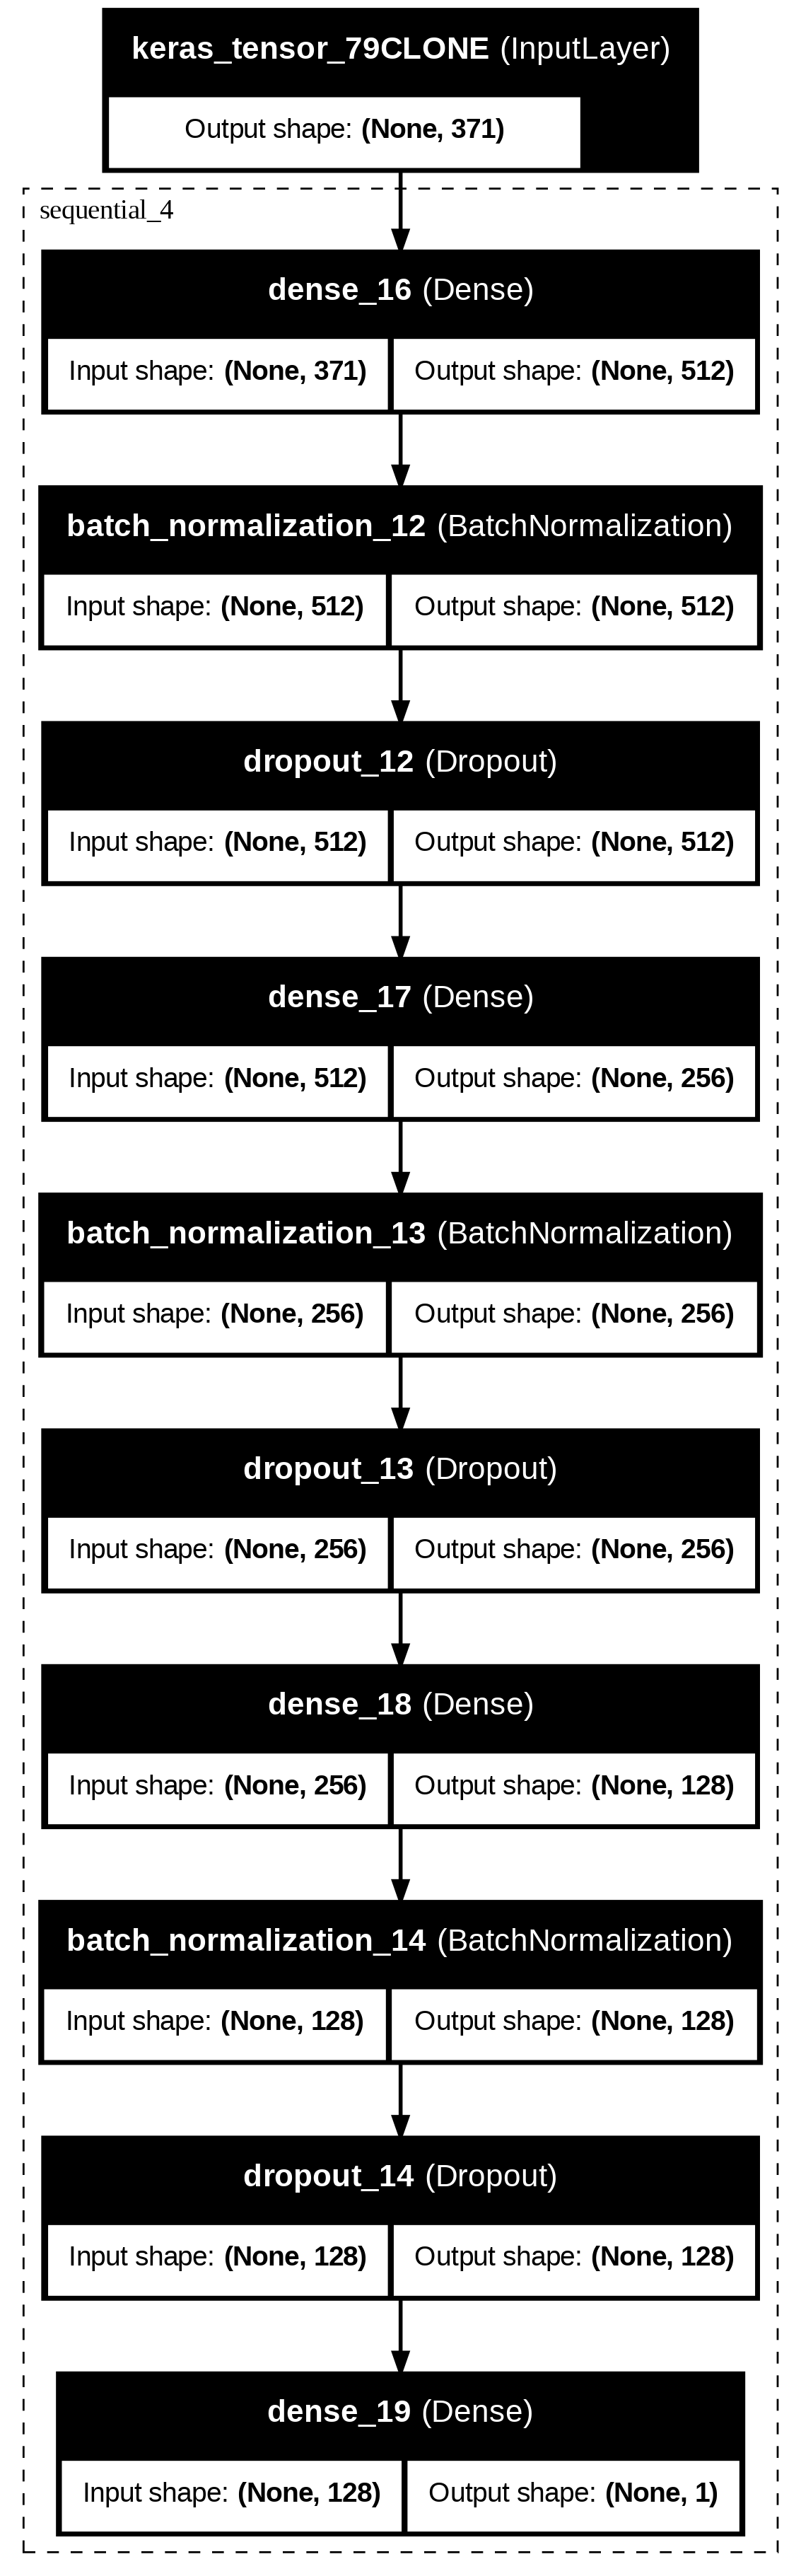

In [41]:
load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")

plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

  0%|          | 0/5 [00:00<?, ?it/s]

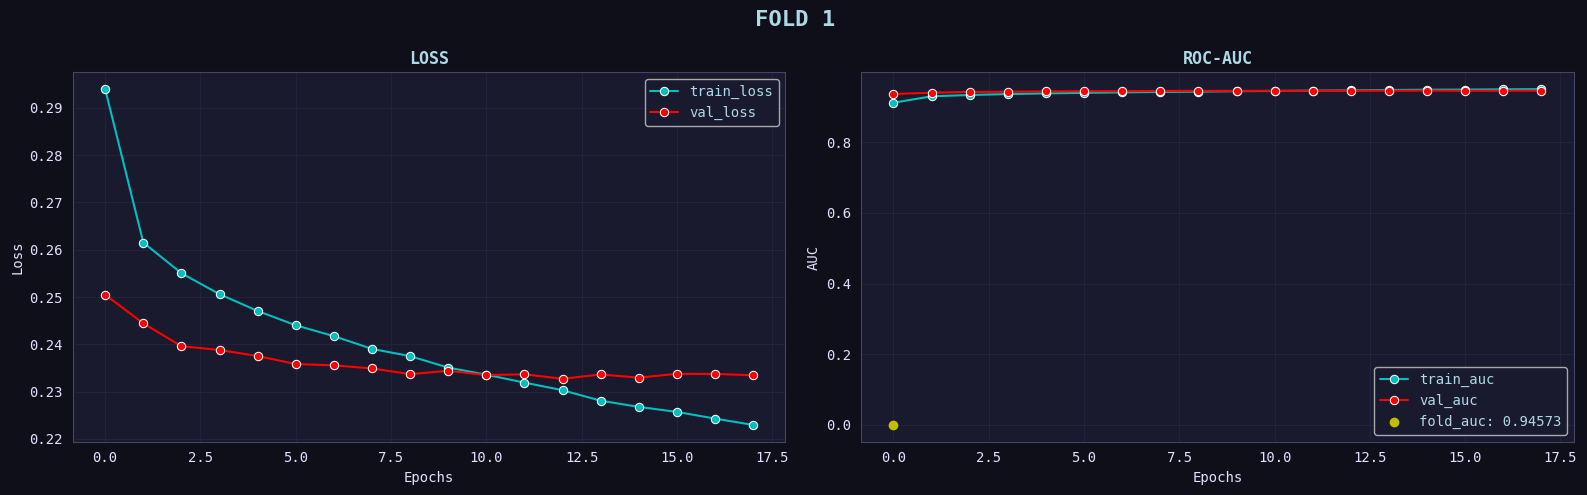

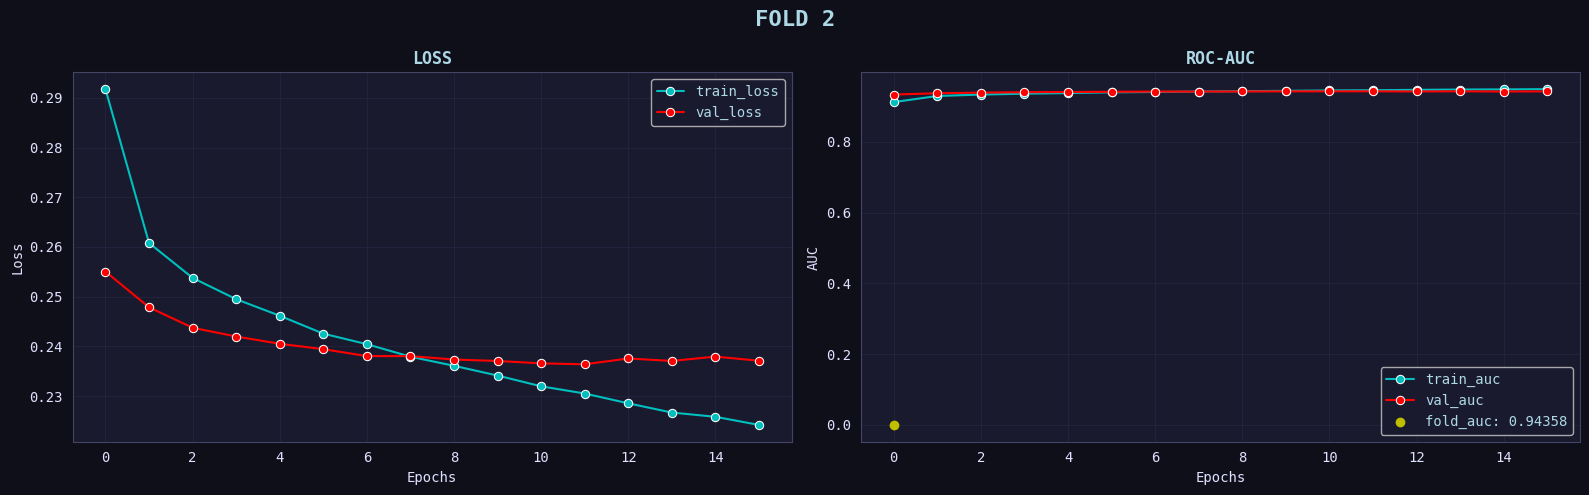

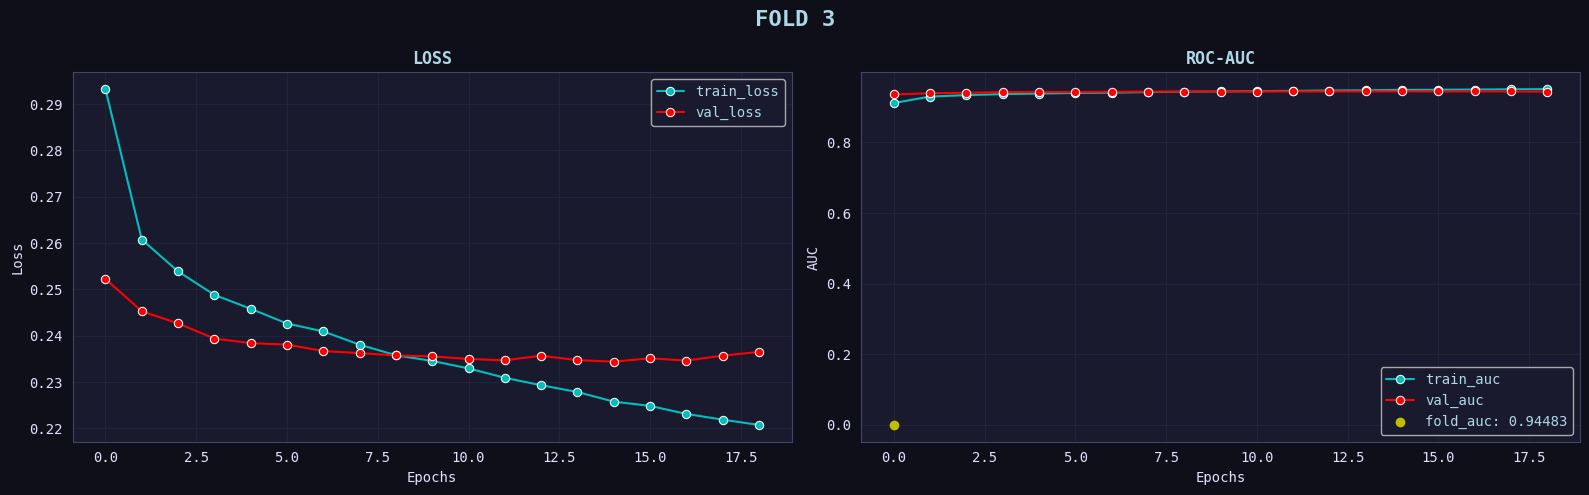

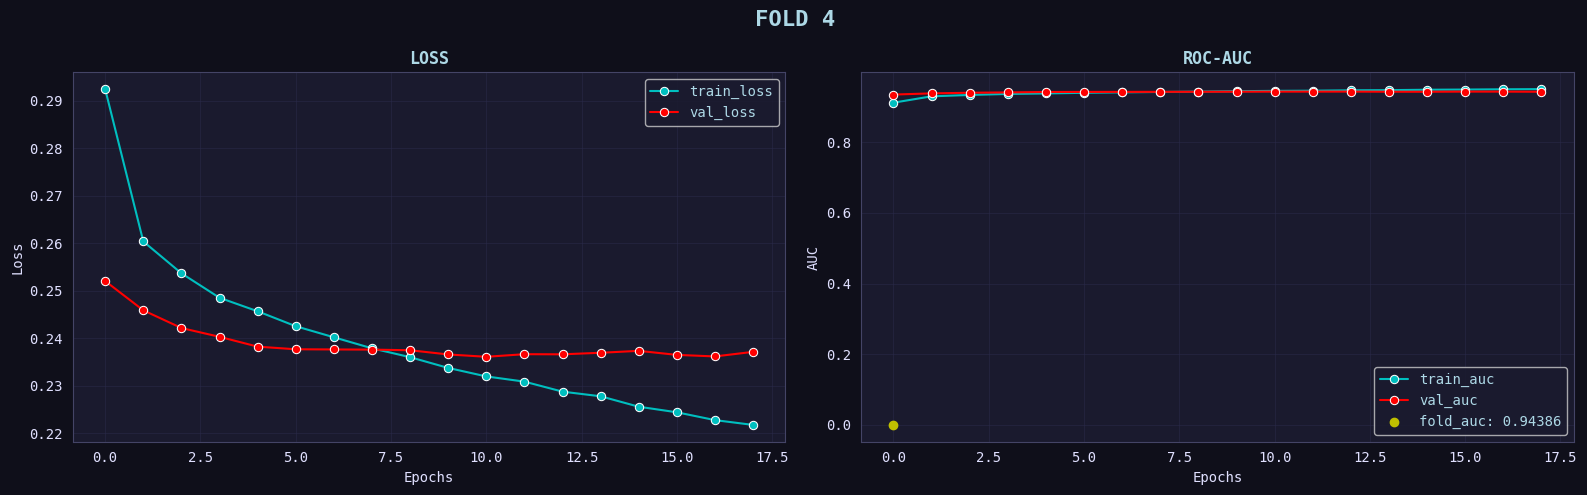

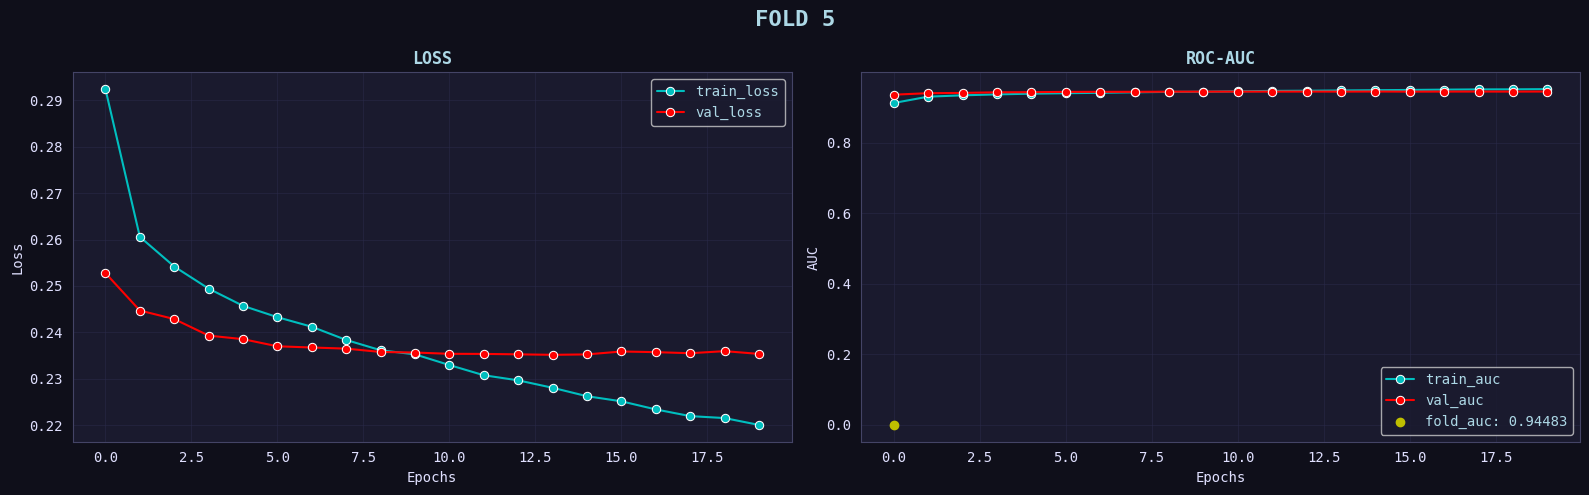

In [42]:
## -- PLOTTING RESULTS --
histories = result['history']

for i, data in tqdm(enumerate(histories), total=len(histories)):
    loss_results = pd.DataFrame({'train_loss': data['loss'], 'val_loss': data['val_loss']})
    auc_results = pd.DataFrame({'train_auc': data['auc'], 'val_auc': data['val_auc']})
    plt.figure(figsize=(16, 5))
    marker = 'o'

    ## -- PLOT LOSS --
    plt.subplot(121)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.train_loss, label='train_loss', marker=marker)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
    plt.title('LOSS', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    ## -- PLOT AUC --
    plt.subplot(122)
    sns.lineplot(auc_results, x=auc_results.index, y=auc_results.train_auc, label='train_auc', marker=marker)
    sns.lineplot(auc_results, x=auc_results.index, y=auc_results.val_auc, label='val_auc', marker=marker)
    plt.title('ROC-AUC', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')

    stat_ = f"fold_auc: {result['fold_score'][i]:.5f}"
    plt.scatter(x=0, y=0, label=stat_, color='y')

    plt.suptitle(f"FOLD {i+1}", fontsize=16, fontweight='semibold')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    print()

Submission saved as: 'submit_kerasFS_v3_94448.csv'


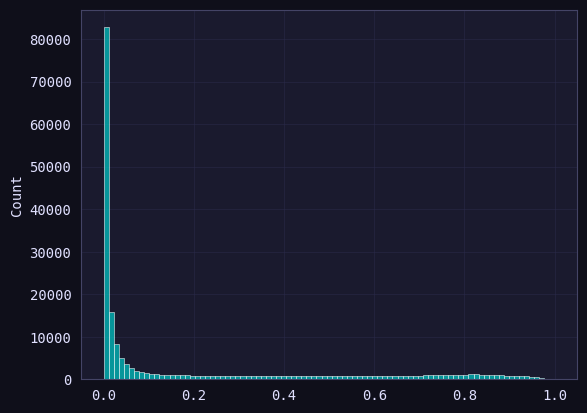

,id,PitNextLap
0,439140,0.004816
1,439141,0.017809
2,439142,0.005946
3,439143,0.196284
4,439144,0.807545
5,439145,0.065063
6,439146,0.000348
7,439147,0.007603
8,439148,0.055101
9,439149,0.001918


In [43]:
n = version_name + str(np.round(np.mean(result['final_score']), 5)).split('.')[1]

np.save(f'oof_{n}.npy', result['oof_preds'])
np.save(f'test_{n}.npy', result['test_preds'])

submit[TARGET] = result['test_preds'].ravel()
submit.to_csv(f"submit_{n}.csv", index=False)

print(f"Submission saved as: 'submit_{n}.csv'")

sns.histplot(submit[TARGET].values)
plt.show()

submit.head(10)